In [4]:
# ============================================================
# OIBSIP - DATA ANALYTICS INTERNSHIP
# TASK 2: CUSTOMER SEGMENTATION ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_excel("Online Retail.xlsx")

print("DATASET SHAPE")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nFIRST 5 ROWS")
display(df.head())

print("\nDATA TYPES")
display(df.dtypes)

print("\nMISSING VALUES")
display(df.isnull().sum())


# ------------------------------------------------------------
# 2. DATA CLEANING
# ------------------------------------------------------------

# Remove rows without Customer ID
df = df.dropna(subset=["CustomerID"])

# Remove cancelled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove invalid quantities and prices
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Calculate total transaction value
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# Remove duplicate records
df = df.drop_duplicates()

print("\nDATA AFTER CLEANING")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


# ------------------------------------------------------------
# 3. DESCRIPTIVE STATISTICS
# ------------------------------------------------------------

average_purchase_value = df["TotalAmount"].mean()

purchase_frequency = (
    df.groupby("CustomerID")["InvoiceNo"]
      .nunique()
      .mean()
)

customer_lifetime_value = (
    df.groupby("CustomerID")["TotalAmount"]
      .sum()
      .mean()
)

print("\nDESCRIPTIVE STATISTICS")
print(f"Average Purchase Value: £{average_purchase_value:.2f}")
print(f"Average Purchase Frequency: {purchase_frequency:.2f} orders")
print(f"Average Customer Lifetime Value: £{customer_lifetime_value:.2f}")


# ------------------------------------------------------------
# 4. RFM ANALYSIS
# ------------------------------------------------------------

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

print("\nRFM DATA")
display(rfm.head())

print("\nRFM STATISTICS")
display(rfm.describe())


# ------------------------------------------------------------
# 5. CHECK RFM DISTRIBUTIONS
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. STANDARDISATION
# ------------------------------------------------------------

features = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[features])

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=features,
    index=rfm.index
)

print("\nSTANDARDISED RFM DATA")
display(rfm_scaled.head())


# ------------------------------------------------------------
# 7. ELBOW METHOD
# ------------------------------------------------------------

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. APPLY K-MEANS
# ------------------------------------------------------------

# Four clusters provide a practical segmentation
# for this customer dataset.

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("\nCUSTOMERS IN EACH CLUSTER")
display(rfm["Cluster"].value_counts().sort_index())


# ------------------------------------------------------------
# 9. CLUSTER PROFILE
# ------------------------------------------------------------

cluster_profile = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

cluster_profile["Customer Count"] = rfm["Cluster"].value_counts()

cluster_profile = cluster_profile.sort_index()

print("\nCLUSTER PROFILE")
display(cluster_profile)


# ------------------------------------------------------------
# 10. CUSTOMER COUNT BY CLUSTER
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=rfm,
    x="Cluster",
    order=sorted(rfm["Cluster"].unique())
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 11. RECENCY VS FREQUENCY
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segments: Recency vs Frequency")
plt.xlabel("Recency (Days)")
plt.ylabel("Purchase Frequency")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12. FREQUENCY VS MONETARY
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segments: Frequency vs Monetary Value")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. MONETARY VS RECENCY
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segments: Recency vs Monetary Value")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 14. IDENTIFY CUSTOMER TYPES
# ------------------------------------------------------------

# Rank clusters using Recency, Frequency and Monetary values.
# Lower Recency is better; higher Frequency and Monetary are better.

profile = cluster_profile.copy()

profile["R_rank"] = profile["Recency"].rank(ascending=True)
profile["F_rank"] = profile["Frequency"].rank(ascending=False)
profile["M_rank"] = profile["Monetary"].rank(ascending=False)

profile["Overall Score"] = (
    profile["R_rank"] +
    profile["F_rank"] +
    profile["M_rank"]
)

best_cluster = profile["Overall Score"].idxmin()

print("\nCUSTOMER SEGMENT INTERPRETATION")

for cluster in profile.index:

    recency = profile.loc[cluster, "Recency"]
    frequency = profile.loc[cluster, "Frequency"]
    monetary = profile.loc[cluster, "Monetary"]

    if cluster == best_cluster:
        segment = "High-Value / Loyal Customers"
        action = "Reward with loyalty benefits, personalised offers and early access to new products."

    elif recency < profile["Recency"].median() and monetary >= profile["Monetary"].median():
        segment = "Potential Loyal Customers"
        action = "Encourage repeat purchases using personalised recommendations and loyalty incentives."

    elif recency > profile["Recency"].median() and monetary >= profile["Monetary"].median():
        segment = "At-Risk Valuable Customers"
        action = "Use win-back campaigns, special discounts and personalised communication."

    else:
        segment = "Low-Engagement Customers"
        action = "Use low-cost promotional campaigns and targeted offers to encourage re-engagement."

    print(f"\nCluster {cluster}: {segment}")
    print(f"Average Recency: {recency:.2f} days")
    print(f"Average Frequency: {frequency:.2f} purchases")
    print(f"Average Monetary Value: £{monetary:.2f}")
    print(f"Recommended Marketing Action: {action}")


# ------------------------------------------------------------
# 15. FINAL BUSINESS INSIGHTS
# ------------------------------------------------------------

print("""
============================================================
CONCLUSION
============================================================

Customer segmentation was performed using RFM analysis and
K-Means clustering.

Recency measures how recently customers purchased, Frequency
measures how often they purchased, and Monetary value measures
how much they spent.

The clustering process divides customers into groups with
similar purchasing behaviour. These segments can help the
business avoid using the same marketing strategy for every
customer.

RECOMMENDATIONS:

1. High-value and loyal customers should receive loyalty
   rewards, personalised recommendations and early access
   to products.

2. At-risk valuable customers should receive win-back
   campaigns and personalised discounts to encourage them
   to return.

3. Low-engagement customers should receive targeted,
   cost-effective promotions designed to increase purchase
   frequency.

4. Customer segments should be monitored regularly because
   customer behaviour can change over time.
""")

print("\nTASK 2 COMPLETED SUCCESSFULLY!")

KeyboardInterrupt: 

### 1. Load Dataset

In [5]:
df = pd.read_excel("Online Retail.xlsx")

print("DATASET SHAPE")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nFIRST 5 ROWS")
display(df.head())

print("\nDATA TYPES")
display(df.dtypes)

print("\nMISSING VALUES")
display(df.isnull().sum())

DATASET SHAPE
Rows: 541909
Columns: 8

FIRST 5 ROWS


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



DATA TYPES


,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object



MISSING VALUES


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


### 2. Data Cleaning

In [6]:
# Remove rows without Customer ID
df = df.dropna(subset=["CustomerID"])

# Remove cancelled transactions
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove invalid quantities and prices
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Calculate total transaction value
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# Remove duplicate records
df = df.drop_duplicates()

print("\nDATA AFTER CLEANING")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


DATA AFTER CLEANING
Rows: 392692
Columns: 9


### 3. Descriptive Statistics

In [7]:
average_purchase_value = df["TotalAmount"].mean()

purchase_frequency = (
    df.groupby("CustomerID")["InvoiceNo"]
      .nunique()
      .mean()
)

customer_lifetime_value = (
    df.groupby("CustomerID")["TotalAmount"]
      .sum()
      .mean()
)

print("\nDESCRIPTIVE STATISTICS")
print(f"Average Purchase Value: £{average_purchase_value:.2f}")
print(f"Average Purchase Frequency: {purchase_frequency:.2f} orders")
print(f"Average Customer Lifetime Value: £{customer_lifetime_value:.2f}")


DESCRIPTIVE STATISTICS
Average Purchase Value: £22.63
Average Purchase Frequency: 4.27 orders
Average Customer Lifetime Value: £2048.69


### 4. RFM Analysis

In [8]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

print("\nRFM DATA")
display(rfm.head())

print("\nRFM STATISTICS")
display(rfm.describe())


RFM DATA


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40



RFM STATISTICS


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


### 5. Check RFM Distributions

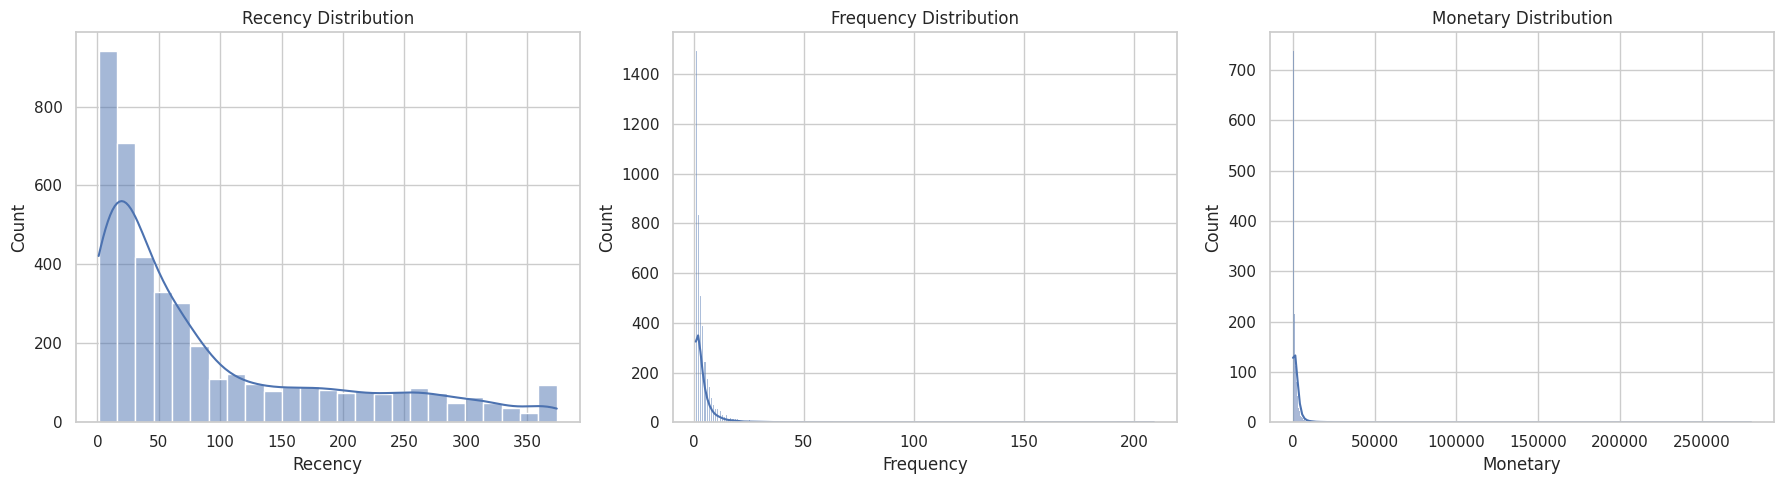

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

### 6. Standardisation

In [10]:
features = ["Recency", "Frequency", "Monetary"]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[features])

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=features,
    index=rfm.index
)

print("\nSTANDARDISED RFM DATA")
display(rfm_scaled.head())


STANDARDISED RFM DATA


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.363010
12347.0,-0.905340,0.354417,0.251699
12348.0,-0.175360,-0.035340,-0.027988
12349.0,-0.735345,-0.425097,-0.032406
12350.0,2.174578,-0.425097,-0.190812


### 7. Elbow Method

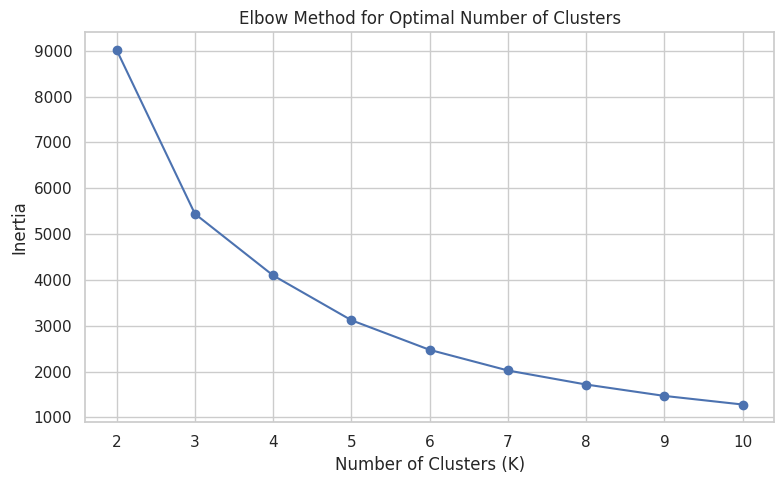

In [11]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

### 8. Apply K-Means

In [12]:
# Four clusters provide a practical segmentation
# for this customer dataset.

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("\nCUSTOMERS IN EACH CLUSTER")
display(rfm["Cluster"].value_counts().sort_index())


CUSTOMERS IN EACH CLUSTER


,count
Cluster,
0,3054
1,1067
2,13
3,204


### 9. Cluster Profile

In [13]:
cluster_profile = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).round(2)

cluster_profile["Customer Count"] = rfm["Cluster"].value_counts()

cluster_profile = cluster_profile.sort_index()

print("\nCLUSTER PROFILE")
display(cluster_profile)


CLUSTER PROFILE


,Recency,Frequency,Monetary,Customer Count
Cluster,,,,
0,43.70,3.68,1353.63,3054
1,248.08,1.55,478.85,1067
2,7.38,82.54,127187.96,13
3,15.50,22.33,12690.50,204


### 10. Customer Count by Cluster

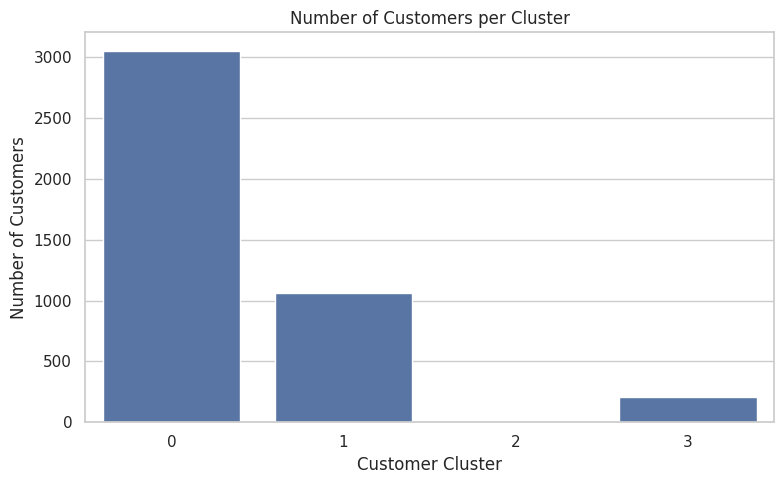

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=rfm,
    x="Cluster",
    order=sorted(rfm["Cluster"].unique())
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### 11. Recency vs Frequency

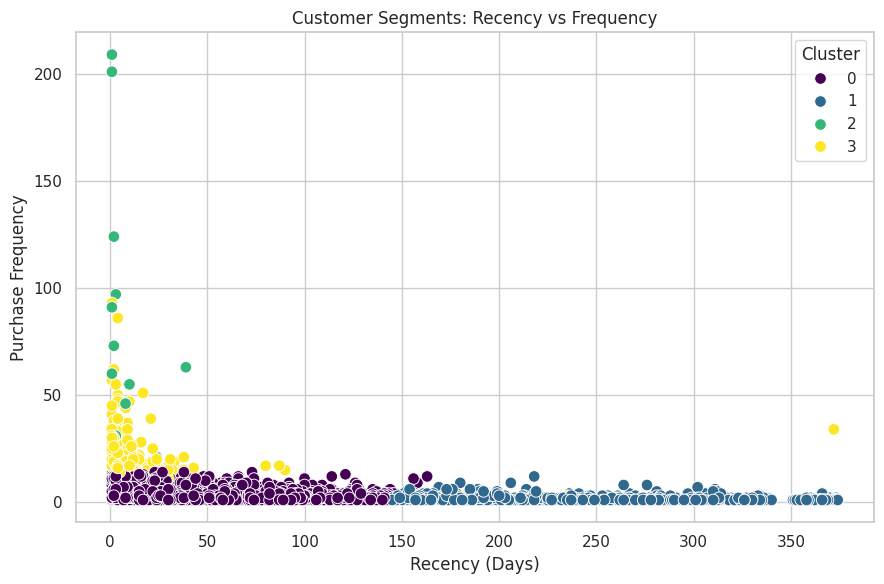

In [15]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segments: Recency vs Frequency")
plt.xlabel("Recency (Days)")
plt.ylabel("Purchase Frequency")
plt.tight_layout()
plt.show()

### 12. Frequency vs Monetary

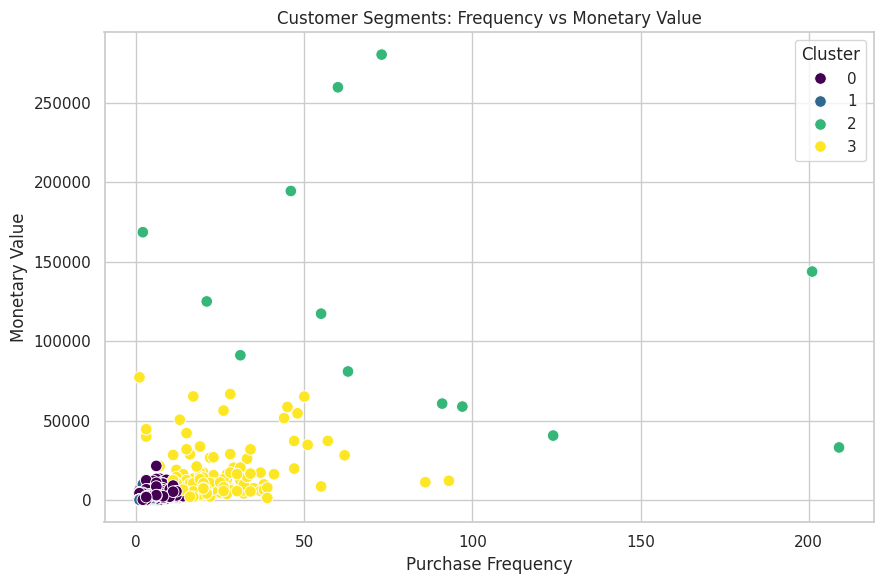

In [16]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segments: Frequency vs Monetary Value")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.tight_layout()
plt.show()

### 13. Monetary vs Recency

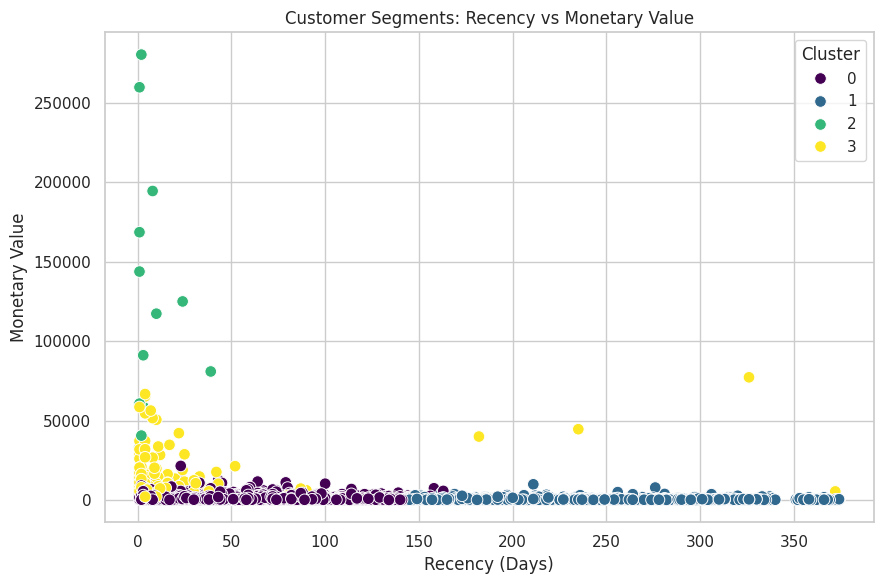

In [17]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segments: Recency vs Monetary Value")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.tight_layout()
plt.show()

### 14. Identify Customer Types

In [18]:
# Rank clusters using Recency, Frequency and Monetary values.
# Lower Recency is better; higher Frequency and Monetary are better.

profile = cluster_profile.copy()

profile["R_rank"] = profile["Recency"].rank(ascending=True)
profile["F_rank"] = profile["Frequency"].rank(ascending=False)
profile["M_rank"] = profile["Monetary"].rank(ascending=False)

profile["Overall Score"] = (
    profile["R_rank"] +
    profile["F_rank"] +
    profile["M_rank"]
)

best_cluster = profile["Overall Score"].idxmin()

print("\nCUSTOMER SEGMENT INTERPRETATION")

for cluster in profile.index:

    recency = profile.loc[cluster, "Recency"]
    frequency = profile.loc[cluster, "Frequency"]
    monetary = profile.loc[cluster, "Monetary"]

    if cluster == best_cluster:
        segment = "High-Value / Loyal Customers"
        action = "Reward with loyalty benefits, personalised offers and early access to new products."

    elif recency < profile["Recency"].median() and monetary >= profile["Monetary"].median():
        segment = "Potential Loyal Customers"
        action = "Encourage repeat purchases using personalised recommendations and loyalty incentives."

    elif recency > profile["Recency"].median() and monetary >= profile["Monetary"].median():
        segment = "At-Risk Valuable Customers"
        action = "Use win-back campaigns, special discounts and personalised communication."

    else:
        segment = "Low-Engagement Customers"
        action = "Use low-cost promotional campaigns and targeted offers to encourage re-engagement."

    print(f"\nCluster {cluster}: {segment}")
    print(f"Average Recency: {recency:.2f} days")
    print(f"Average Frequency: {frequency:.2f} purchases")
    print(f"Average Monetary Value: £{monetary:.2f}")
    print(f"Recommended Marketing Action: {action}")


CUSTOMER SEGMENT INTERPRETATION

Cluster 0: Low-Engagement Customers
Average Recency: 43.70 days
Average Frequency: 3.68 purchases
Average Monetary Value: £1353.63
Recommended Marketing Action: Use low-cost promotional campaigns and targeted offers to encourage re-engagement.

Cluster 1: Low-Engagement Customers
Average Recency: 248.08 days
Average Frequency: 1.55 purchases
Average Monetary Value: £478.85
Recommended Marketing Action: Use low-cost promotional campaigns and targeted offers to encourage re-engagement.

Cluster 2: High-Value / Loyal Customers
Average Recency: 7.38 days
Average Frequency: 82.54 purchases
Average Monetary Value: £127187.96
Recommended Marketing Action: Reward with loyalty benefits, personalised offers and early access to new products.

Cluster 3: Potential Loyal Customers
Average Recency: 15.50 days
Average Frequency: 22.33 purchases
Average Monetary Value: £12690.50
Recommended Marketing Action: Encourage repeat purchases using personalised recommendation

### 15. Final Business Insights

In [19]:
print("""
============================================================
CONCLUSION
============================================================

Customer segmentation was performed using RFM analysis and
K-Means clustering.

Recency measures how recently customers purchased, Frequency
measures how often they purchased, and Monetary value measures
how much they spent.

The clustering process divides customers into groups with
similar purchasing behaviour. These segments can help the
business avoid using the same marketing strategy for every
customer.

RECOMMENDATIONS:

1. High-value and loyal customers should receive loyalty
   rewards, personalised recommendations and early access
   to products.

2. At-risk valuable customers should receive win-back
   campaigns and personalised discounts to encourage them
   to return.

3. Low-engagement customers should receive targeted,
   cost-effective promotions designed to increase purchase
   frequency.

4. Customer segments should be monitored regularly because
   customer behaviour can change over time.
""")

print("\nTASK 2 COMPLETED SUCCESSFULLY!")


CONCLUSION

Customer segmentation was performed using RFM analysis and
K-Means clustering.

Recency measures how recently customers purchased, Frequency
measures how often they purchased, and Monetary value measures
how much they spent.

The clustering process divides customers into groups with
similar purchasing behaviour. These segments can help the
business avoid using the same marketing strategy for every
customer.

RECOMMENDATIONS:

1. High-value and loyal customers should receive loyalty
   rewards, personalised recommendations and early access
   to products.

2. At-risk valuable customers should receive win-back
   campaigns and personalised discounts to encourage them
   to return.

3. Low-engagement customers should receive targeted,
   cost-effective promotions designed to increase purchase
   frequency.

4. Customer segments should be monitored regularly because
   customer behaviour can change over time.


TASK 2 COMPLETED SUCCESSFULLY!
